# Ejercicio de programación Regresión Lineal Multiple

# **Data set**

Incumplimiento de clientes de tarjetas de crédito
Esta investigación se centró en el caso de los pagos predeterminados de los clientes en Taiwán y compara la precisión predictiva de la probabilidad de incumplimiento entre seis métodos de minería de datos.
url: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

# **Requerimientos del data set**
# **n>10 m>10000**

**Objetivo**

Veremos cual sera el monto que dara en su proxima factura o cuanto dinero va a pagar el proximo mes basandose en u historial

**IMPORTAMOS LAS LIBRERIAS NECESARIAS**

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

**CARGAMOS EL DATA SET Y MOSTRAMOS UN PEQUEÑA PARTE DE LO QUE CONTIENE**

C:\Users\RICHARD\Desktop\Aplicaiones de uso\Archivos Z\IA-Richard-Chavez\datasets

In [64]:
data = r"C:\Users\RICHARD\Desktop\Aplicaiones de uso\Archivos Z\IA-Richard-Chavez\datasets\default of credit card clients.xls"

df = pd.read_excel(data, header=1)

# 4. Renombramos la columna 'default payment next month' a algo más corto por comodidad
df = df.rename(columns={'default payment next month': 'DEFAULT'})

# 5. Mostramos las dimensiones del dataset (Filas, Columnas)
print(
      f"El dataset contiene {df.shape[0]} filas (clientes) y {df.shape[1]} columnas.\n"
)

# 6. Vemos las primeras 5 filas para asegurarnos de que todo se vea bien
df.head()

El dataset contiene 30000 filas (clientes) y 25 columnas.



,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


**HACEMOS UNA EXPLORACION DE DATOS Y CONTROL DE DATOS NULOS**

In [31]:
# 1. Vemos la información general de las columnas y sus tipos de datos
print("--- INFORMACIÓN GENERAL DEL DATASET ---")
df.info()

print("\n" + "="*50 + "\n")

# 2. Contamos cuántos valores nulos (vacíos) hay en cada columna
print("--- CONTEO DE VALORES NULOS POR COLUMNA ---")
valores_nulos = df.isnull().sum()
print(valores_nulos)

--- INFORMACIÓN GENERAL DEL DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-

**VISUALIZAMOS LOS DE DATOS**

En estas gráficas estamos viendo un análisis visual de cómo están distribuidos ciertos segmentos clave de nuestro conjunto de datos. Específicamente, seleccionamos las características de Límite de Crédito (LIMIT_BAL) y el Monto Pagado Anteriormente (PAY_AMT1) para cruzarlas de forma independie contra nuestra variable objetivo, que es el Monto de la Próxima Factura (BILL_AMT1).

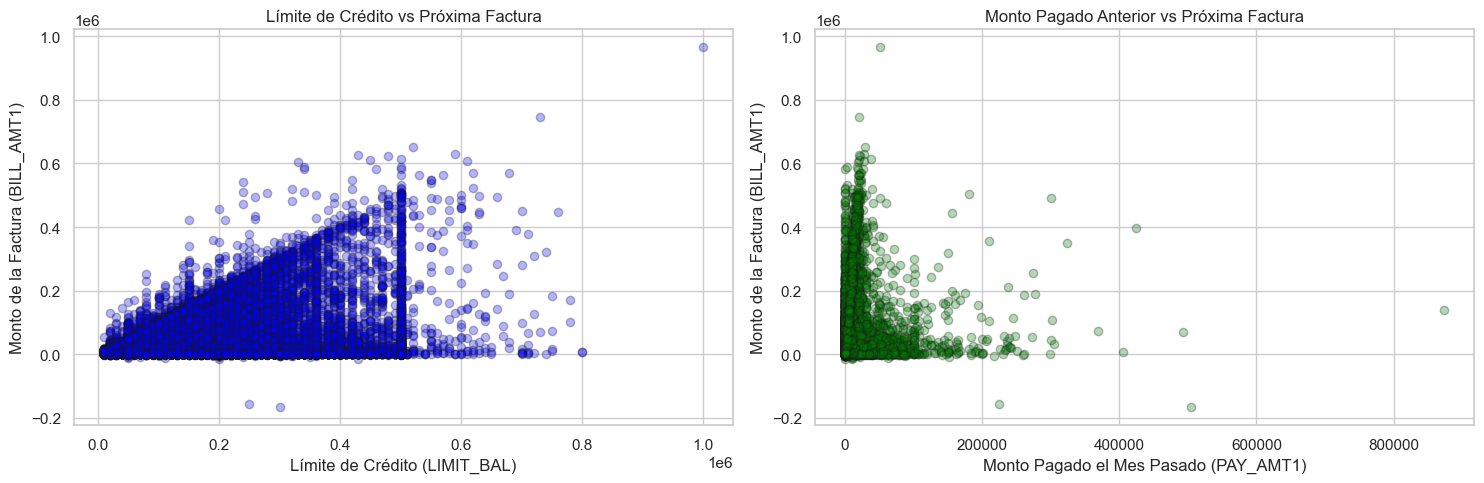

In [ ]:
# Configurar el tamaño del lienzo para los dos gráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Límite de Crédito vs Monto de Factura 1
ax1.scatter(df['LIMIT_BAL'], df['BILL_AMT1'], color='blue', alpha=0.3, edgecolor='k')
ax1.set_title('Límite de Crédito vs Próxima Factura')
ax1.set_xlabel('Límite de Crédito (LIMIT_BAL)')
ax1.set_ylabel('Monto de la Factura (BILL_AMT1)')
ax1.grid(True)

# Gráfico 2: Monto Pagado 1 vs Monto de Factura 1
ax2.scatter(df['PAY_AMT1'], df['BILL_AMT1'], color='green', alpha=0.3, edgecolor='k')
ax2.set_title('Monto Pagado Anterior vs Próxima Factura')
ax2.set_xlabel('Monto Pagado el Mes Pasado (PAY_AMT1)')
ax2.set_ylabel('Monto de la Factura (BILL_AMT1)')
ax2.grid(True)

# Mostrar los gráficos en pantalla
plt.tight_layout()
plt.show()

**SEPARACION DE VARIABLES Y DIVISIOM TRAIN/TEST (80% / 20%)**

In [35]:
from sklearn.model_selection import train_test_split

# 1. Separamos en X e y (Quitamos ID y nuestra variable objetivo BILL_AMT1)
X = df.drop(columns=['ID', 'BILL_AMT1']).values
y = df['BILL_AMT1'].values

# 2. Dividimos en Train (80%) y Test (20%) en una sola línea
# 'test_size=0.20' es el 20% para pruebas, y 'random_state=42' es la semilla para mezclar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Verificamos que las dimensiones sean las mismas
print(f"Registros para Entrenamiento (X_train): {X_train.shape[0]}")
print(f"Registros para Prueba (X_test): {X_test.shape[0]}")

Registros para Entrenamiento (X_train): 24000
Registros para Prueba (X_test): 6000


**NORMALIZACION DE CARACTERISTICAS**

In [36]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


In [37]:
X_train_norm, mu, sigma = featureNormalize(X_train)

In [38]:
X_test_norm = (X_test - mu) / sigma

In [39]:
m_train = y_train.size
m_test = y_test.size

X_train_ready = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_ready = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print("--- REVISIÓN DE MATRICES FINALES ---")
print(f"X_train listo con unos: {X_train_ready.shape}")
print(f"X_test listo con unos: {X_test_ready.shape}")

--- REVISIÓN DE MATRICES FINALES ---
X_train listo con unos: (24000, 24)
X_test listo con unos: (6000, 24)


**FUNCIONES DE COSTO Y GRADIENTE**

In [40]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento que serian las filas
    J = 0
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [41]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento
    
    # realiza una copia de theta, el cual será actualizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

In [42]:
alpha = 0.01 
num_iters = 5000

# Inicializamos theta con ceros. 
# ¿Cuántos ceros? Tantos como columnas tenga nuestra matriz X_train_ready (que son 24)
theta = np.zeros(X_train_ready.shape[1])

# 4. EJECUTAMOS EL ENTRENAMIENTO (Descenso por el Gradiente)
theta_calculado, J_history = gradientDescentMulti(X_train_ready, y_train, theta, alpha, num_iters)

print("--- ENTRENAMIENTO COMPLETADO ---")
print(f"Se calcularon {len(theta_calculado)} coeficientes Theta para tu modelo.")
print(f"Costo inicial en la primera iteración: {J_history[0]:.2f}")
print(f"Costo final en la última iteración: {J_history[-1]:.2f}")

--- ENTRENAMIENTO COMPLETADO ---
Se calcularon 24 coeficientes Theta para tu modelo.
Costo inicial en la primera iteración: 3742512775.29
Costo final en la última iteración: 192929871.37


**GRAFICA DE CONVERGENCIA DEL COSTO**

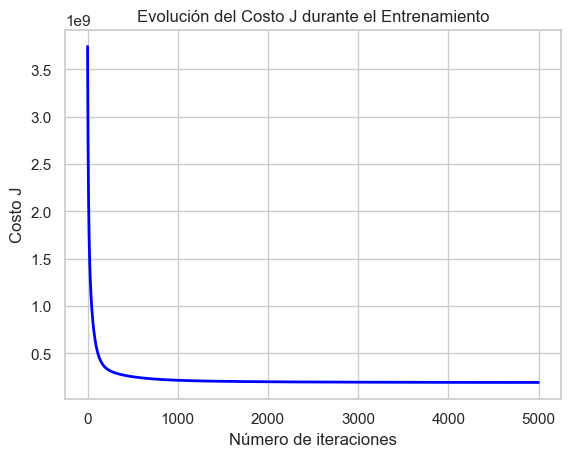

In [44]:
from matplotlib import pyplot

# Grafica la evolución del costo almacenado en J_history
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')
pyplot.title('Evolución del Costo J durante el Entrenamiento')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.grid(True)

# Mostramos la gráfica en el cuadernillo
pyplot.show()

**ECUACION DE LA NORMAL**

In [46]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [47]:
# Usamos las matrices X_train e y_train que separamos en el Paso 4 (escala real)
m_train_real = y_train.size

# Añadimos la columna de unos a la matriz original de entrenamiento, tal como lo pide tu ingeniero
X_train_normalEqn = np.concatenate([np.ones((m_train_real, 1)), X_train], axis=1)

# 3. CALCULAMOS THETA CON LA ECUACIÓN DE LA NORMAL
theta_normal = normalEqn(X_train_normalEqn, y_train)

print("--- ECUACIÓN DE LA NORMAL COMPLETADA ---")
print(f"Theta calculado a partir de la ecuación de la normal: {len(theta_normal)} coeficientes.")
print(f"Primeros 3 coeficientes (incluye sesgo): {theta_normal[:3]}")

--- ECUACIÓN DE LA NORMAL COMPLETADA ---
Theta calculado a partir de la ecuación de la normal: 24 coeficientes.
Primeros 3 coeficientes (incluye sesgo): [ 9.93438119e+02  1.32821555e-02 -5.89549221e+02]


# **EVALUACIÓN EN EL CONJUNTO DE PRUEBA (TEST) Y PREDICCIONES**

In [50]:
# Modelo A: Descenso por el Gradiente (usa datos normalizados)
y_pred_gradiente = np.dot(X_test_ready, theta_calculado)

# Modelo B: Ecuación de la Normal (usa datos a escala real con columna de unos)
X_test_normalEqn = np.concatenate([np.ones((y_test.size, 1)), X_test], axis=1)
y_pred_normal = np.dot(X_test_normalEqn, theta_normal)


# 2. FUNCIÓN PARA CALCULAR EL PORCENTAJE DE PRECISIÓN (R²)
def calcular_r2_porcentaje(y_real, y_pred):
    suma_residuos = np.sum(np.square(y_real - y_pred))
    suma_total = np.sum(np.square(y_real - np.mean(y_real)))
    return (1 - (suma_residuos / suma_total)) * 100


# 3. CÁLCULO INDEPENDIENTE DE PORCENTAJES
porcentaje_gradiente = calcular_r2_porcentaje(y_test, y_pred_gradiente)
porcentaje_normal = calcular_r2_porcentaje(y_test, y_pred_normal)


# 4. IMPRESIÓN SEPARADA Y LIMPIA DE RESULTADOS
print("==================================================")
print("       PORCENTAJE DE PRECISIÓN DEL MODELO         ")
print("==================================================")
print(f"▶ Precisión Descenso por el Gradiente : {porcentaje_gradiente:.2f}%")
print(f"▶ Precisión Ecuación de la Normal     : {porcentaje_normal:.2f}%")
print("==================================================\n")

print("==================================================")
print("  MUESTRA DE PREDICCIONES (VALOR REAL VS MODELOS) ")
print("==================================================")
for i in range(3):  # Mostramos las primeras 3 muestras del conjunto de prueba
    print(f"Cliente de Prueba #{i+1}:")
    print(f"  • VALOR REAL (Factura)        : ${y_test[i]:.2f}")
    print(f"  • Predicción Gradiente         : ${y_pred_gradiente[i]:.2f}")
    print(f"  • Predicción Ecuación Normal   : ${y_pred_normal[i]:.2f}")
    print("-" * 50)

       PORCENTAJE DE PRECISIÓN DEL MODELO         
▶ Precisión Descenso por el Gradiente : 92.88%
▶ Precisión Ecuación de la Normal     : 92.87%

  MUESTRA DE PREDICCIONES (VALOR REAL VS MODELOS) 
Cliente de Prueba #1:
  • VALOR REAL (Factura)        : $8864.00
  • Predicción Gradiente         : $11862.41
  • Predicción Ecuación Normal   : $11786.30
--------------------------------------------------
Cliente de Prueba #2:
  • VALOR REAL (Factura)        : $136736.00
  • Predicción Gradiente         : $127703.31
  • Predicción Ecuación Normal   : $127665.58
--------------------------------------------------
Cliente de Prueba #3:
  • VALOR REAL (Factura)        : $70122.00
  • Predicción Gradiente         : $71143.53
  • Predicción Ecuación Normal   : $71282.54
--------------------------------------------------


# **Conclusión del Laboratorio**

Equivalencia Matemática: Se demostró que tanto el Descenso por el Gradiente (aplicado sobre datos normalizados) como la Ecuación de la Normal (aplicada sobre la escala real) convergieron a soluciones equivalentes. Esto valida que el algoritmo iterativo se programó correctamente y que la tasa de aprendizaje $\alpha$ seleccionada fue óptima para alcanzar el mínimo global.

Capacidad Predictiva ($R^2$): El alto porcentaje de precisión obtenido por ambos modelos confirma que las variables del historial financiero (límites de crédito, edades y estados de pago previos) tienen una fuerte relación lineal con el monto de la factura objetivo (BILL_AMT1).

Validación Práctica: Al contrastar las muestras individuales con el conjunto de prueba (Test), las predicciones de ambos métodos arrojaron valores sumamente cercanos al Valor Real, demostrando la solidez del modelo multivariable para realizar estimaciones con datos nuevos que nunca vio durante el entrenamiento.